In [3]:
import os

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv
from torch.utils.data import Dataset, DataLoader
##########################################
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from PIL import Image, ImageFile
####################################
import matplotlib.pyplot as plt
from skimage import io, transform
from PIL import Image
from torchvision.io import decode_image
ImageFile.LOAD_TRUNCATED_IMAGES=True

In [4]:
#path = 'Jupyter_notebook/Kaggle/CropsData/Crop_details.csv'
path_csv = 'CropsData/Crop_details.csv'

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

cuda


In [5]:
classes = {
    0: "jute",
    1: "maize",
    2: "rice",
    3: "sugarcane",
    4: "wheat"
}

In [27]:
df = pd.read_csv(path_csv, encoding='latin1')
#df.to_numpy() # Maakt er een numpy array van. Belangrijk!
df.head()

,Unnamed: 0,path,crop,croplabel
0,0,/kaggle/input/kag2/sugarcane/sugarcane037ahs.jpeg,sugarcane,3
1,1,/kaggle/input/kag2/sugarcane/sugarcane034a.jpeg,sugarcane,3
2,2,/kaggle/input/kag2/sugarcane/sugarcane032arot....,sugarcane,3
3,3,/kaggle/input/kag2/sugarcane/sugarcane036ahs.jpeg,sugarcane,3
4,4,/kaggle/input/kag2/sugarcane/sugarcane023ahs.jpeg,sugarcane,3


In [7]:
class CropsDataset(Dataset):
    def __init__(self, dataframe,transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):           
        img_name = os.path.join('CropsData/',self.dataframe.iloc[idx, 1][14:])
        image = Image.open(img_name).convert("RGB")
        
        label = int(self.dataframe.croplabel[idx])
        #label = np.array([label], dtype=float)
        
        sample = {'image': image, 'label': label  }
        
        if self.transform:
            image = self.transform(image)

        sample = {'image': image, 'label': label  }
        #print(type(sample['image']))
        
        return sample

In [8]:
# NB! Ik heb de transform overgenomen van voorbeeld van chapter 2

img_transforms = transforms.Compose([
    transforms.Resize((64,64)),    
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225] )
    ])



In [9]:
df_dataset = CropsDataset (df, transform=img_transforms)
#df_dataset = CropsDataset (df)
print('df_dataset: ', type(df_dataset))
for sample in df_dataset:
    X, y = sample['image'], sample['label']
    print ('sample: ', type(sample))
    print('X, y', type(X), type(y))
    #print(X)
    break

# def show_crops_from_data(image, label):
#     """Show image with landmarks"""
#     plt.title (label)
#     plt.imshow(image.permute(1, 2, 0))

# sample = df_dataset[180]
# label = classes[int(sample['label'].item())]
# print (label)
# X, y= sample['image'], sample['label']
#show_crops_from_data(X, label)
#break

df_dataset:  <class '__main__.CropsDataset'>
sample:  <class 'dict'>
X, y <class 'torch.Tensor'> <class 'int'>


In [10]:
train_data, val_data, test_data = torch.utils.data.random_split(df_dataset, [0.75, 0.1, 0.15])

In [11]:
batch_size=64

In [12]:
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size)
val_data_loader  = torch.utils.data.DataLoader(val_data, batch_size=batch_size) 
test_data_loader  = torch.utils.data.DataLoader(test_data, batch_size=batch_size) 

In [13]:
for sample in train_data_loader:
    X, y = sample['image'], sample['label']
    print(type(X), type(y))
    break

<class 'torch.Tensor'> <class 'torch.Tensor'>


In [14]:
class SimpleNet(nn.Module):

    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(12288, 84)
        self.fc2 = nn.Linear(84, 50)
        self.fc3 = nn.Linear(50,5)
    
    def forward(self, x):
        x = x.view(-1, 12288)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [15]:
simplenet = SimpleNet()

In [16]:
optimizer = optim.Adam(simplenet.parameters(), lr=0.001)

In [17]:
if torch.cuda.is_available():
    device = torch.device("cuda") 
else:
    device = torch.device("cpu")

simplenet.to(device)

SimpleNet(
  (fc1): Linear(in_features=12288, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=5, bias=True)
)

In [18]:
def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="cpu"):
    for epoch in range(1, epochs+1):
        training_loss = 0.0
        valid_loss = 0.0
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            inputs, targets = batch['image'], batch['label']
            inputs = inputs.to(device)
            targets = targets.to(device)
            output = model(inputs)
            loss = loss_fn(output, targets)
            loss.backward()
            optimizer.step()
            training_loss += loss.data.item() * inputs.size(0)
        training_loss /= len(train_loader.dataset)
        
        model.eval()
        num_correct = 0 
        num_examples = 0
        for batch in val_loader:
            inputs, targets = batch['image'], batch['label']
            inputs = inputs.to(device)
            output = model(inputs)
            targets = targets.to(device)
            loss = loss_fn(output,targets) 
            valid_loss += loss.data.item() * inputs.size(0)
            correct = torch.eq(torch.max(F.softmax(output, dim=1), dim=1)[1], targets)
            num_correct += torch.sum(correct).item()
            num_examples += correct.shape[0]
        valid_loss /= len(val_loader.dataset)
        
        print('Epoch: {}, Training Loss: {:.2f}, Validation Loss: {:.2f}, accuracy = {:.2f}'.format(epoch, training_loss,
        valid_loss, num_correct / num_examples))

In [21]:
# sanity check
# (van chatGTP na 'corrupted context gpu' en nadat de kernel gereset heb)
labels = df['croplabel']
print(labels.min(), labels.max(), labels.unique())


0 4 [3 4 0 1 2]


In [71]:
train(simplenet, optimizer,torch.nn.CrossEntropyLoss(), train_data_loader,val_data_loader, epochs=25, device=device)

Epoch: 1, Training Loss: 0.00, Validation Loss: 0.43, accuracy = 0.89
Epoch: 2, Training Loss: 0.00, Validation Loss: 0.43, accuracy = 0.89
Epoch: 3, Training Loss: 0.00, Validation Loss: 0.44, accuracy = 0.89
Epoch: 4, Training Loss: 0.00, Validation Loss: 0.44, accuracy = 0.89
Epoch: 5, Training Loss: 0.00, Validation Loss: 0.44, accuracy = 0.89
Epoch: 6, Training Loss: 0.00, Validation Loss: 0.44, accuracy = 0.89
Epoch: 7, Training Loss: 0.00, Validation Loss: 0.44, accuracy = 0.89
Epoch: 8, Training Loss: 0.00, Validation Loss: 0.44, accuracy = 0.89
Epoch: 9, Training Loss: 0.00, Validation Loss: 0.45, accuracy = 0.89
Epoch: 10, Training Loss: 0.00, Validation Loss: 0.45, accuracy = 0.89
Epoch: 11, Training Loss: 0.00, Validation Loss: 0.45, accuracy = 0.89
Epoch: 12, Training Loss: 0.00, Validation Loss: 0.45, accuracy = 0.89
Epoch: 13, Training Loss: 0.00, Validation Loss: 0.45, accuracy = 0.89
Epoch: 14, Training Loss: 0.00, Validation Loss: 0.45, accuracy = 0.89
Epoch: 15, Trai

In [23]:
torch.save(simplenet, "tmp/simplenet") 
#simplenet = torch.load("tmp/simplenet", weights_only=False)    # True gives error. See the error for more explaination

CropsData/crop_images/sugarcane/sugarcane037a.jpeg sugarcane
The prediction is sugarcane
tensor(3, device='cuda:0')


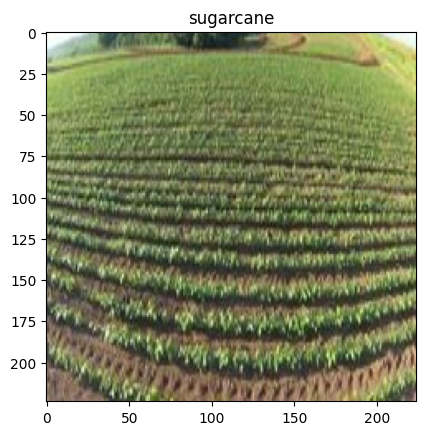

In [73]:
n = 810

test_X = "CropsData"+df.path[n][13:]
test_y = df.croplabel[n]
print(test_X, classes[test_y])

img = Image.open(test_X)

plt.imshow(img)
plt.title(classes[test_y])

img = img_transforms(img).to(device)
img = torch.unsqueeze(img, 0)

simplenet.eval()
prediction = F.softmax(simplenet(img), dim=1)
prediction = prediction.argmax()
print('The prediction is', classes[int(prediction.item())]) 
print(prediction)